In [4]:
import pandas as pd


rfm = pd.read_csv("../Data/Cleaned data/rfm_base.csv")

In [5]:
rfm.head()

,customer_id,last_purchase,frequency,monetary
0,C078,2023-11-02,9,44597.0
1,C095,2023-12-10,11,45692.0
2,C096,2023-12-02,3,12240.0
3,C011,2023-12-17,7,15042.0
4,C046,2023-12-05,14,29150.0


In [6]:
# Convert last_purchase to datetime
rfm['last_purchase'] = pd.to_datetime(rfm['last_purchase'])

In [7]:
# Calculate Recency (Defining reference date)

reference_date = rfm['last_purchase'].max()

rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

In [8]:
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,C078,2023-11-02,9,44597.0,57
1,C095,2023-12-10,11,45692.0,19
2,C096,2023-12-02,3,12240.0,27
3,C011,2023-12-17,7,15042.0,12
4,C046,2023-12-05,14,29150.0,24


In [9]:
# Create R, F, M Scores (1 to 5 scale)
# Recency (lower is better → reverse scoring)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])

In [10]:
# Frequency (higher is better)
rfm['F_score'] = pd.qcut(rfm['frequency'], 5, labels=[1,2,3,4,5])

In [11]:

# Monetary (higher is better)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

In [12]:
# Convert Scores to Integer

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [13]:
# Create Combined RFM Score
rfm['RFM_segment'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [14]:
# Create Customer Segmentation Logic
def segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] == 1:
        return 'Lost Customers'
    else:
        return 'Potential'

rfm['Customer_Type'] = rfm.apply(segment, axis=1)

In [15]:
# Check Segment Distribution
rfm['Customer_Type'].value_counts()

Customer_Type
Potential          33
Loyal Customers    27
At Risk            17
Lost Customers     12
Champions          11
Name: count, dtype: int64

Business Insight

Potential customers form the largest segment, indicating strong opportunity for conversion to loyal customers.

Champions represent a smaller group but typically drive high value.

In [16]:
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_segment,Customer_Type
0,C078,2023-11-02,9,44597.0,57,1,2,5,125,Lost Customers
1,C095,2023-12-10,11,45692.0,19,4,3,5,435,Loyal Customers
2,C096,2023-12-02,3,12240.0,27,4,1,1,411,Potential
3,C011,2023-12-17,7,15042.0,12,5,1,1,511,Potential
4,C046,2023-12-05,14,29150.0,24,4,5,2,452,Loyal Customers


In [17]:
# average spend per segment

rfm.groupby('Customer_Type')['monetary'].mean()

Customer_Type
At Risk            42218.470588
Champions          51498.727273
Lost Customers     26882.250000
Loyal Customers    36903.222222
Potential          27812.424242
Name: monetary, dtype: float64

Business Insight:

Champions show the highest average spending per customer.

Loyal customers provide stable recurring revenue.

Lost customers show declining engagement and represent churn.

In [18]:
# Revenue Contribution per Segment
rfm.groupby('Customer_Type')['monetary'].sum().sort_values(ascending=False)

Customer_Type
Loyal Customers    996387.0
Potential          917810.0
At Risk            717714.0
Champions          566486.0
Lost Customers     322587.0
Name: monetary, dtype: float64

Business Insight:

Loyal and Champion customers contribute the majority of total revenue.

At Risk customers still hold significant monetary value and should be targeted with retention campaigns.

In [19]:
# Percentage Contribution
segment_revenue = rfm.groupby('Customer_Type')['monetary'].sum()
(segment_revenue / segment_revenue.sum()) * 100

Customer_Type
At Risk            20.383904
Champions          16.088855
Lost Customers      9.161842
Loyal Customers    28.298538
Potential          26.066861
Name: monetary, dtype: float64

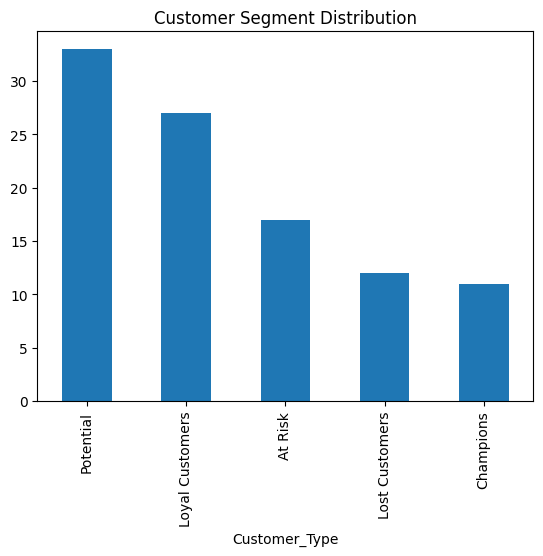

In [20]:
# Visualization 

import matplotlib.pyplot as plt

rfm['Customer_Type'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.show()

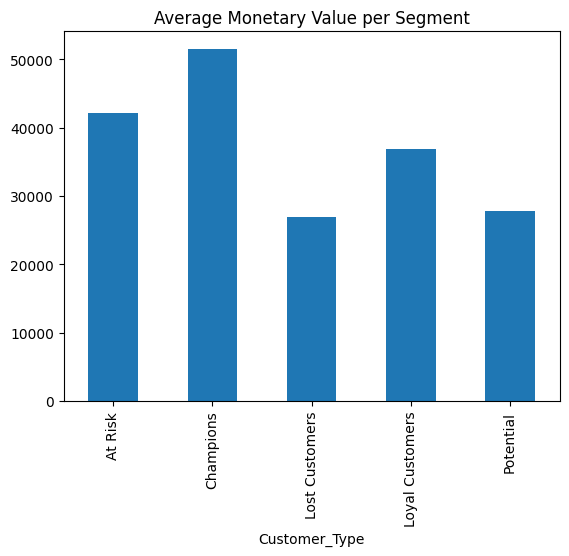

In [36]:
rfm.groupby('Customer_Type')['monetary'].mean().plot(kind='bar')
plt.title("Average Monetary Value per Segment")
plt.show()

In [37]:
segment_summary = rfm.groupby('Customer_Type').agg({
    'customer_id':'count',
    'monetary':'sum'
}).reset_index()

segment_summary

,Customer_Type,customer_id,monetary
0,At Risk,17,717714.0
1,Champions,11,566486.0
2,Lost Customers,12,322587.0
3,Loyal Customers,27,996387.0
4,Potential,33,917810.0


In [38]:
# Add Segment Revenue Percentage (Business KPI)

segment_summary['revenue_percent'] = (
    segment_summary['monetary'] / segment_summary['monetary'].sum() * 100
).round(2)

segment_summary

,Customer_Type,customer_id,monetary,revenue_percent
0,At Risk,17,717714.0,20.38
1,Champions,11,566486.0,16.09
2,Lost Customers,12,322587.0,9.16
3,Loyal Customers,27,996387.0,28.30
4,Potential,33,917810.0,26.07


In [39]:
# Add Average Customer Value per Segment

segment_summary['avg_customer_value'] = (
    segment_summary['monetary'] / segment_summary['customer_id']
).round(2)

segment_summary

,Customer_Type,customer_id,monetary,revenue_percent,avg_customer_value
0,At Risk,17,717714.0,20.38,42218.47
1,Champions,11,566486.0,16.09,51498.73
2,Lost Customers,12,322587.0,9.16,26882.25
3,Loyal Customers,27,996387.0,28.30,36903.22
4,Potential,33,917810.0,26.07,27812.42


In [40]:
# Identify High-Value Customers (VIP List)

top_customers = rfm.sort_values(by='monetary', ascending=False).head(10)
top_customers

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_segment,Customer_Type,CLV_estimate
29,C020,2023-12-19,16,75029.0,10,5,5,5,555,Champions,1200464.0
22,C044,2023-10-24,17,70409.0,66,1,5,5,155,At Risk,1196953.0
10,C045,2023-12-15,15,61294.0,14,5,5,5,555,Champions,919410.0
74,C024,2023-12-23,14,59666.0,6,5,5,5,555,Champions,835324.0
18,C099,2023-12-24,17,53082.0,5,5,5,5,555,Champions,902394.0
13,C051,2023-12-15,14,50856.0,14,5,5,5,555,Champions,711984.0
49,C061,2023-11-27,13,50313.0,32,3,5,5,355,Loyal Customers,654069.0
17,C008,2023-12-22,16,50151.0,7,5,5,5,555,Champions,802416.0
52,C032,2023-11-14,13,49494.0,45,3,5,5,355,Loyal Customers,643422.0
80,C084,2023-12-19,13,49100.0,10,5,5,5,555,Champions,638300.0


In [41]:
# Detect Churn Risk Customers
churn_risk = rfm[rfm['Customer_Type'].isin(['At Risk','Lost Customers'])]

churn_risk[['customer_id','recency','frequency','monetary']].head()

,customer_id,recency,frequency,monetary
0,C078,57,9,44597.0
6,C055,56,10,46022.0
9,C040,54,11,41660.0
11,C030,123,12,48097.0
15,C070,85,11,39355.0


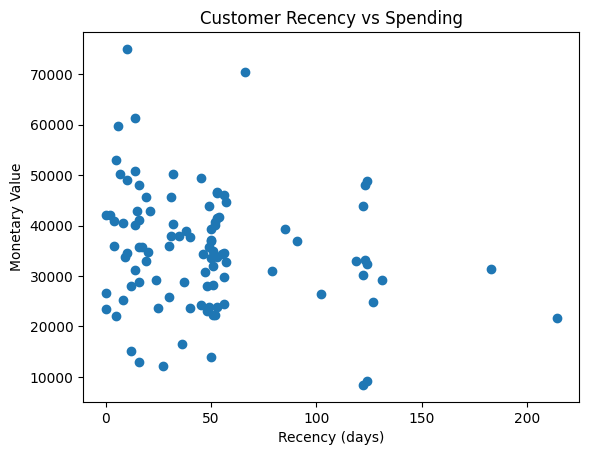

In [42]:
# Add Recency vs Monetary Scatter Plot
plt.scatter(rfm['recency'], rfm['monetary'])
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.title("Customer Recency vs Spending")
plt.show()

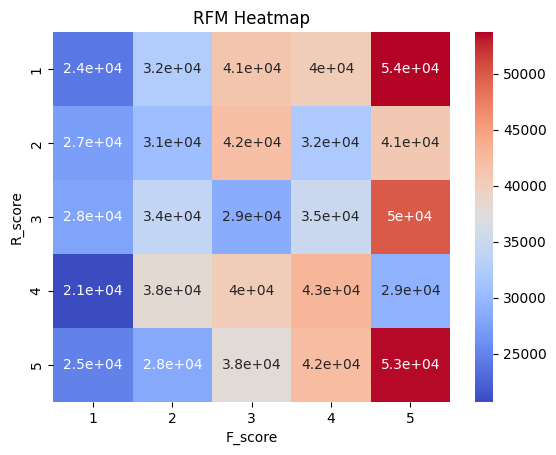

In [43]:
# Create RFM Heatmap 
import seaborn as sns
import matplotlib.pyplot as plt

rfm_pivot = rfm.pivot_table(
    index='R_score',
    columns='F_score',
    values='monetary',
    aggfunc='mean'
)

sns.heatmap(rfm_pivot, annot=True, cmap='coolwarm')

plt.title("RFM Heatmap")
plt.show()

In [44]:
# Add Customer Lifetime Value Estimate

rfm['CLV_estimate'] = rfm['monetary'] * rfm['frequency']

rfm[['customer_id','CLV_estimate']].sort_values(
    by='CLV_estimate', ascending=False
).head(10)

,customer_id,CLV_estimate
29,C020,1200464.0
22,C044,1196953.0
10,C045,919410.0
18,C099,902394.0
74,C024,835324.0
17,C008,802416.0
13,C051,711984.0
49,C061,654069.0
52,C032,643422.0
80,C084,638300.0


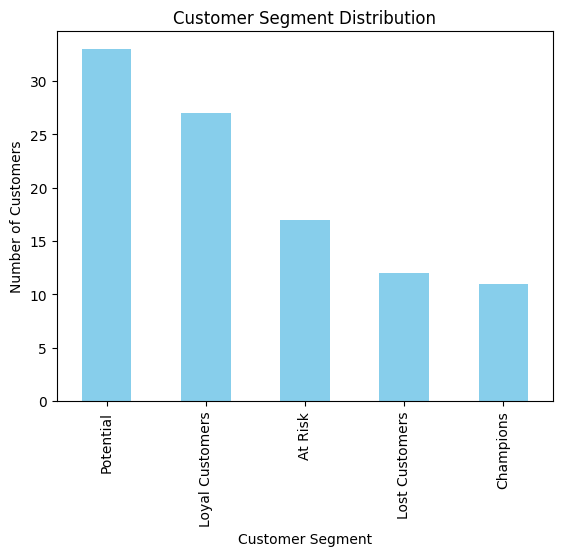

In [45]:
# Segment Size Visualization (Better Chart)

rfm['Customer_Type'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

Business Insight:

Customer distribution highlights a large pool of Potential customers that can be nurtured into loyal segments.

Marketing strategies should focus on moving customers up the value ladder.

In [46]:
# Analytics Output File

segment_summary.to_csv("../Data/Cleaned data/segment_summary.csv", index=False)

Final Business Insights & Strategic Recommendations:

Key Insights---

Champions represent the most valuable customers with high recency, frequency, and spending behavior.

Loyal customers provide a stable revenue base and should be retained through loyalty programs.

Potential customers form the largest group and represent an opportunity for growth through targeted promotions.

At Risk customers previously generated high value but show declining engagement, indicating potential churn.

Lost customers represent churned users who may require reactivation campaigns.


Strategic Recommendations---

Offer loyalty rewards and exclusive deals to Champions.

Upsell premium products to Loyal Customers.

Provide targeted promotions to Potential customers to increase purchase frequency.

Launch retention campaigns for At Risk customers.

Run re-engagement campaigns for Lost customers.